# ASL Hand Sign Classification — TFLite + MediaPipe
Labels: **A–Z** (0–25), **del** (26), **nothing** (27), **space** (28)

## ⚙️ Cell 1 — Configuration
**Edit only this cell**, then run all cells.

In [1]:
# ─────────────────────────────────────────────
#  CONFIGURATION  ← edit these variables
# ─────────────────────────────────────────────

# Path to your .tflite model file
MODEL_PATH = "/home/rafayahmadraza/SignBuddy/Models/asl_alphabet_model.tflite"

# Camera index (0 = default webcam, 1 = second camera, etc.)
CAMERA_INDEX = 0

# Confidence threshold — predictions below this show in orange
CONFIDENCE_THRESHOLD = 0.5

# Optional: path to a custom labels.json (leave as None to use built-in labels)
LABELS_JSON_PATH = "/home/rafayahmadraza/SignBuddy/Models/labels.json"   # e.g. "labels.json"
# ─────────────────────────────────────────────

## Cell 2 — Imports & setup

In [2]:
!pip install mediapipe opencv-python numpy tflite-runtime "numpy<2" mediapipe==0.10.9


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import json
import os
import time

import cv2
import mediapipe as mp
import numpy as np
from IPython.display import display, Image as IPyImage

# Try tflite_runtime first, fall back to full TensorFlow
try:
    import tflite_runtime.interpreter as tflite
    Interpreter = tflite.Interpreter
    print("[INFO] Using tflite_runtime")
except ImportError:
    try:
        import tensorflow as tf
        Interpreter = tf.lite.Interpreter
        print("[INFO] Using tensorflow.lite.Interpreter")
    except ImportError:
        raise ImportError(
            "Neither tflite_runtime nor tensorflow is installed.\n"
            "Run:  pip install tflite-runtime"
        )

mp_hands          = mp.solutions.hands
mp_drawing        = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
print("[INFO] Imports OK")

2026-04-27 08:38:34.663309: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-27 08:38:34.669170: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-27 08:38:34.685947: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777261114.719058    9521 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777261114.726791    9521 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-27 08:38:34.753860: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

[INFO] Using tflite_runtime
[INFO] Imports OK


## Cell 3 — Labels

In [4]:
LABELS = {
    0:"A",  1:"B",  2:"C",  3:"D",  4:"E",  5:"F",
    6:"G",  7:"H",  8:"I",  9:"J",  10:"K", 11:"L",
    12:"M", 13:"N", 14:"O", 15:"P", 16:"Q", 17:"R",
    18:"S", 19:"T", 20:"U", 21:"V", 22:"W", 23:"X",
    24:"Y", 25:"Z", 26:"del", 27:"nothing", 28:"space"
}

if LABELS_JSON_PATH:
    with open(LABELS_JSON_PATH) as f:
        raw = json.load(f)
    LABELS = {int(k): v for k, v in raw.items()}
    print(f"[INFO] Loaded {len(LABELS)} labels from {LABELS_JSON_PATH}")
else:
    print(f"[INFO] Using built-in labels ({len(LABELS)} classes)")

print(LABELS)

[INFO] Loaded 29 labels from /home/rafayahmadraza/SignBuddy/Models/labels.json
{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y', 25: 'Z', 26: 'del', 27: 'nothing', 28: 'space'}


## Cell 4 — Helper functions

In [5]:
def extract_landmarks(image_rgb, hands_detector):
    """Return flat (63,) landmark array + hand_landmarks object, or (None, None)."""
    results = hands_detector.process(image_rgb)
    if not results.multi_hand_landmarks:
        return None, None
    hand_lms = results.multi_hand_landmarks[0]
    coords = []
    for lm in hand_lms.landmark:
        coords.extend([lm.x, lm.y, lm.z])
    return np.array(coords, dtype=np.float32), hand_lms


def normalize_landmarks(landmarks: np.ndarray) -> np.ndarray:
    """Translate wrist to origin, scale to [-1, 1]."""
    pts = landmarks.reshape(21, 3)
    pts = pts - pts[0]
    max_val = np.max(np.abs(pts))
    if max_val > 0:
        pts = pts / max_val
    return pts.flatten()


def annotate_frame(frame_bgr, hand_lms, label: str, conf: float, fps: float):
    """Draw landmarks + HUD text on a copy of the frame."""
    out = frame_bgr.copy()
    if hand_lms:
        mp_drawing.draw_landmarks(
            out, hand_lms, mp_hands.HAND_CONNECTIONS,
            mp_drawing_styles.get_default_hand_landmarks_style(),
            mp_drawing_styles.get_default_hand_connections_style()
        )
    color = (0, 255, 0) if conf >= CONFIDENCE_THRESHOLD else (0, 165, 255)
    cv2.putText(out, f"Sign: {label}",        (10, 50),  cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 3)
    cv2.putText(out, f"Conf: {conf*100:.1f}%",(10, 100), cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)
    cv2.putText(out, f"FPS:  {fps:.1f}",
                (10, out.shape[0] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)
    return out


def bgr_to_jpeg_bytes(frame_bgr, quality: int = 80) -> bytes:
    """Encode a BGR frame as JPEG bytes for inline notebook display."""
    _, buf = cv2.imencode(".jpg", frame_bgr, [cv2.IMWRITE_JPEG_QUALITY, quality])
    return buf.tobytes()


print("[INFO] Helper functions defined")

[INFO] Helper functions defined


## Cell 5 — Load model

In [6]:
class TFLiteClassifier:
    def __init__(self, model_path: str):
        if not os.path.isfile(model_path):
            raise FileNotFoundError(f"Model not found: {model_path}")
        self.interpreter = Interpreter(model_path=model_path)
        self.interpreter.allocate_tensors()
        self.input_details  = self.interpreter.get_input_details()
        self.output_details = self.interpreter.get_output_details()
        self.input_shape    = self.input_details[0]['shape']
        print(f"[INFO] Model loaded   : {model_path}")
        print(f"[INFO] Input shape    : {self.input_shape}")
        print(f"[INFO] Output classes : {self.output_details[0]['shape']}")

    def predict(self, features: np.ndarray):
        inp = features.reshape(self.input_shape).astype(np.float32)
        self.interpreter.set_tensor(self.input_details[0]['index'], inp)
        self.interpreter.invoke()
        output = self.interpreter.get_tensor(self.output_details[0]['index'])[0]
        # Apply softmax if the model outputs raw logits
        if output.max() > 1.0 or output.min() < 0.0:
            e = np.exp(output - output.max())
            output = e / e.sum()
        pred_idx   = int(np.argmax(output))
        confidence = float(output[pred_idx])
        return pred_idx, confidence, output


classifier = TFLiteClassifier(MODEL_PATH)

[INFO] Model loaded   : /home/rafayahmadraza/SignBuddy/Models/asl_alphabet_model.tflite
[INFO] Input shape    : [ 1 63]
[INFO] Output classes : [ 1 29]


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## Cell 6 — Live webcam (inline)
The annotated video stream renders **directly in this cell's output** — no pop-up window.

▶ **Start:** run this cell  
⏹ **Stop:** run **Cell 7** below, or press the ■ *Interrupt kernel* button in the toolbar.

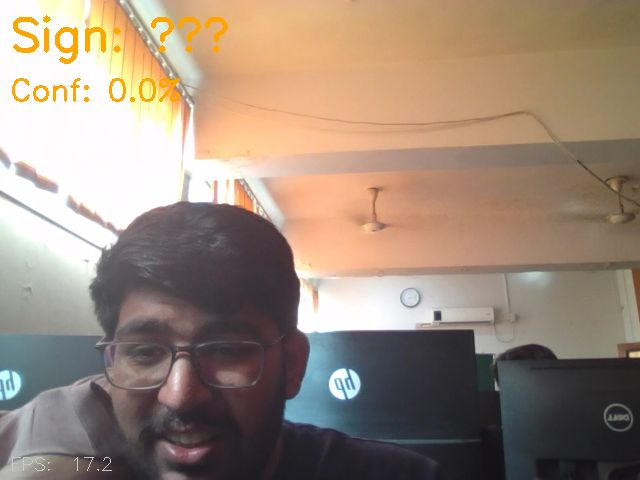

[INFO] Webcam started — run Cell 7 to stop


I0000 00:00:1777261129.977058    9521 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1777261129.983219    9639 gl_context.cc:344] GL version: 3.2 (OpenGL ES 3.2 Mesa 26.0.5), renderer: Mesa Intel(R) UHD Graphics (CML GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


[INFO] Webcam released


KeyboardInterrupt: 

In [7]:
stop_webcam = False   # Cell 7 flips this to True

cap = cv2.VideoCapture(CAMERA_INDEX)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open camera index {CAMERA_INDEX}")

# Single display handle — each update replaces the previous frame
display_handle = display(IPyImage(data=b""), display_id=True)

fps_time    = time.time()
frame_count = 0
print("[INFO] Webcam started — run Cell 7 to stop")

try:
    with mp_hands.Hands(
        static_image_mode=False,
        max_num_hands=1,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as hands:
        while not stop_webcam:
            ret, frame = cap.read()
            if not ret:
                print("[WARN] Frame capture failed — stopping.")
                break

            frame = cv2.flip(frame, 1)                           # mirror
            rgb   = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            landmarks, hand_lms = extract_landmarks(rgb, hands)

            label, conf = "—", 0.0
            if landmarks is not None:
                features          = normalize_landmarks(landmarks)
                pred_idx, conf, _ = classifier.predict(features)
                label             = LABELS.get(pred_idx, "?")

            frame_count += 1
            fps = frame_count / (time.time() - fps_time + 1e-6)

            annotated = annotate_frame(frame, hand_lms, label, conf, fps)

            # Push JPEG bytes — replaces the previous frame inline
            display_handle.update(IPyImage(data=bgr_to_jpeg_bytes(annotated)))

finally:
    cap.release()
    print("[INFO] Webcam released")

## Cell 7 — Stop webcam
Run this cell to gracefully stop the live feed.

In [ ]:
stop_webcam = True
print("[INFO] Stop signal sent — webcam will close after the current frame.")